# Knowledge graph of the OSDR metadata

Building a knowledge graph from OSDR study metadata to reveal how missions, organisms, assays and factors interconnect — the figures used in the ISSOP analyses.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

# Load the data
import os
file_path = next(p for p in ('genelab_osd.txt', 'chapters/genelab_osd.txt') if os.path.exists(p))
data = pd.read_csv(file_path, delimiter='\t')
data = data.dropna(subset=['measurementType', 'technologyType'], how='all')
data['Factors'] = data['Factors'].fillna('')

# Minor error/formatting corrections to data
data['technologyType'] = data['technologyType'].replace('single-cell RNA Sequencing', 'single-cell RNA sequencing')

data['technologyType'] = data['technologyType'].replace('DNA microarray', 'microarray')

# Helper function to sort measures into omics categories
def assign_category(measurement_type):
    categories = {
        'genomics': ["genome sequencing", "copy number variation profiling",
                         "deletion pool profiling", "Amplicon Sequencing",
                         "Genome-wide Association Study"],
            'transcriptomics': ["transcription profiling", "RNA methylation profiling"],
            'proteomics': ["protein expression profiling", "protein quantification",
                           "phosphoprotein profiling", "protein-DNA binding site identification",
                           "protein identification"],
            'metabolomics': ["metabolite profiling"],
            'epigenomics': ["DNA methylation profiling", "Chromatin Accessibility"],
            'metagenomics': ["metagenome profiling",
                                                          "Metagenomic sequencing",
                                                          "environmental gene survey"],
            'non-omics': ["Molecular Cellular Imaging", "Behavior", "Bone Microstructure",
                          "Echocardiogram", "Histological Assay", "Image Analysis",
                          "Morphometric analysis", "Bone biomechanical measurement",
                          "Calcium Uptake", "histology", "Flow Cytometry"]
        }

    for category, measurements in categories.items():
        if measurement_type in measurements:
            return category

    return "Uncategorized"

# Assign an omics type to each row based on measurementType
data['Category'] = data['measurementType'].apply(assign_category)

# category counts
print(data['Category'].value_counts())


# this is same classification that Henry decidid for his figure

Category
transcriptomics    467
non-omics           76
genomics            70
Uncategorized       59
proteomics          53
epigenomics         35
metagenomics        26
metabolomics        12
Name: count, dtype: int64


In [2]:
data

,accession,measurementType,technologyType,Factors,Category
0,OSD-1,transcription profiling,microarray,Spaceflight;Infection,transcriptomics
1,OSD-2,transcription profiling,microarray,Ionizing Radiation;Absorbed Radiation Dose,transcriptomics
2,OSD-3,transcription profiling,microarray,Developmental Stage;Spaceflight,transcriptomics
3,OSD-4,transcription profiling,microarray,Spaceflight,transcriptomics
4,OSD-5,transcription profiling,microarray,Microgravity Simulation,transcriptomics
...,...,...,...,...,...
793,OSD-990,transcription profiling,RNA Sequencing (RNA-Seq),Hypergravity;Hypergravity Duration;Total Incub...,transcriptomics
794,OSD-992,transcription profiling,single-cell RNA sequencing,Ionizing Radiation;Treatment Group,transcriptomics
795,OSD-993,transcription profiling,RNA Sequencing (RNA-Seq),Ionizing Radiation;Treatment Group,transcriptomics
796,OSD-998,transcription profiling,RNA Sequencing (RNA-Seq),Hypergravity;Time of Sample Collection After T...,transcriptomics


Table of Factors counts:
Factors
Spaceflight                                                                         135
Spaceflight;Age                                                                      23
Microgravity Simulation                                                              22
Spaceflight;Time                                                                     21
Spaceflight;Organism Part                                                            14
                                                                                   ... 
Spaceflight;Co-culture;Donor Medical History                                          1
Hindlimb Unloading;Genotype                                                           1
Ionizing Radiation;Absorbed Radiation Dose;Ploidy;Growth Condition Design;Strain      1
Hypergravity;Hypergravity Duration;Total Incubation Time                              1
Hypergravity;Time of Sample Collection After Treatment                                1

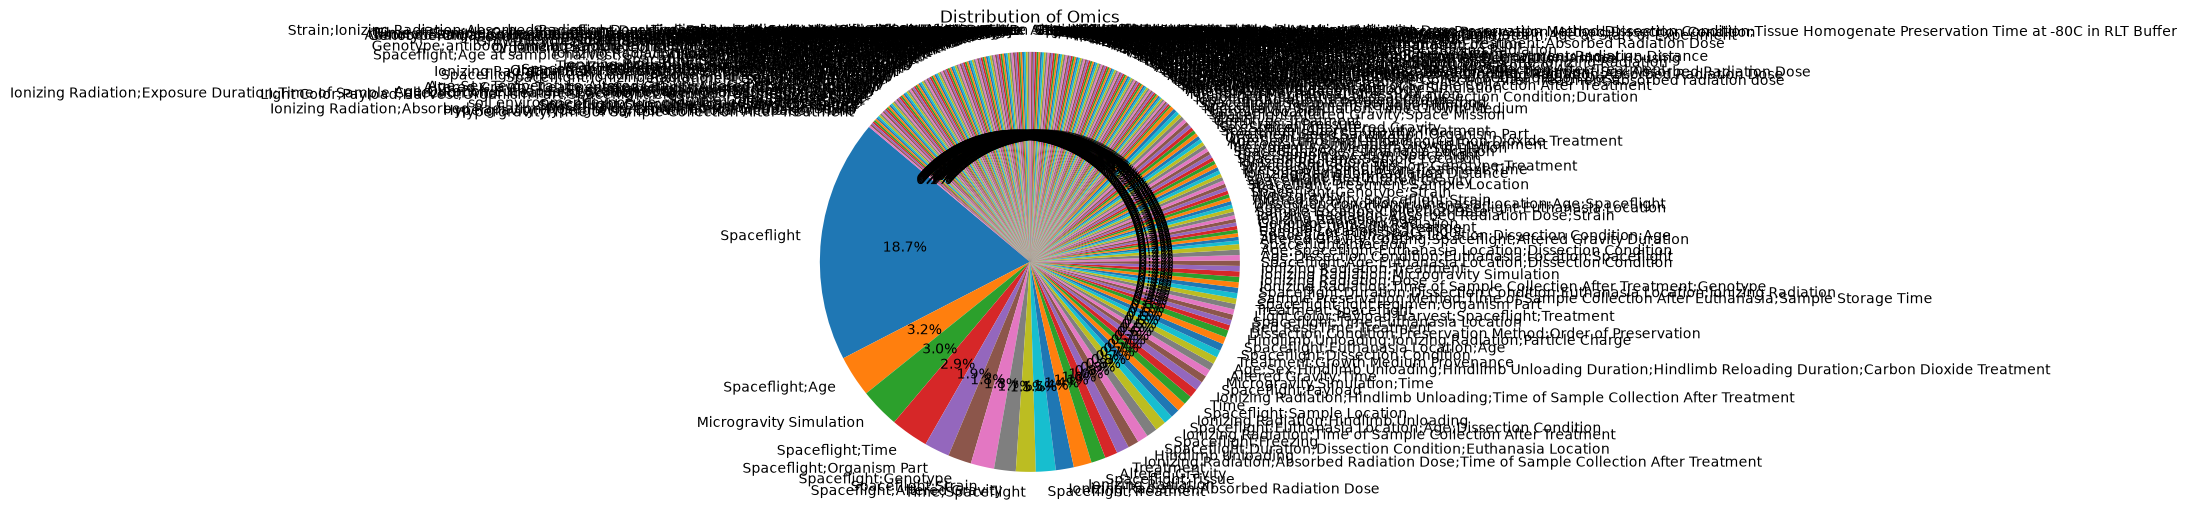

In [3]:
# Drop non-omics rows
indices_to_drop = data[data['Category'] == 'non-omics'].index
omics_data = data.drop(indices_to_drop) # data

omics_category_counts = omics_data['Factors'].value_counts()

# table of unique omics and their counts
print("Table of Factors counts:")
print(omics_category_counts)

#  plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(omics_category_counts, labels=omics_category_counts.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Distribution of Omics')
plt.show()

In [4]:
omics_data

,accession,measurementType,technologyType,Factors,Category
0,OSD-1,transcription profiling,microarray,Spaceflight;Infection,transcriptomics
1,OSD-2,transcription profiling,microarray,Ionizing Radiation;Absorbed Radiation Dose,transcriptomics
2,OSD-3,transcription profiling,microarray,Developmental Stage;Spaceflight,transcriptomics
3,OSD-4,transcription profiling,microarray,Spaceflight,transcriptomics
4,OSD-5,transcription profiling,microarray,Microgravity Simulation,transcriptomics
...,...,...,...,...,...
793,OSD-990,transcription profiling,RNA Sequencing (RNA-Seq),Hypergravity;Hypergravity Duration;Total Incub...,transcriptomics
794,OSD-992,transcription profiling,single-cell RNA sequencing,Ionizing Radiation;Treatment Group,transcriptomics
795,OSD-993,transcription profiling,RNA Sequencing (RNA-Seq),Ionizing Radiation;Treatment Group,transcriptomics
796,OSD-998,transcription profiling,RNA Sequencing (RNA-Seq),Hypergravity;Time of Sample Collection After T...,transcriptomics


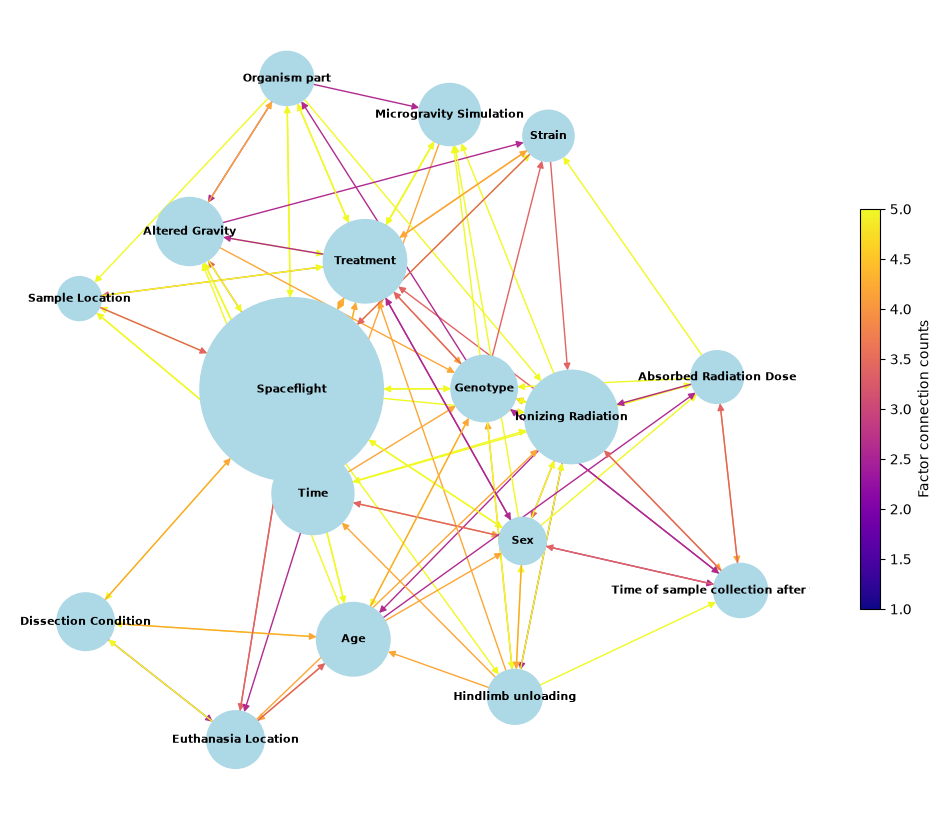

In [5]:

import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import random

# Sample rows of factors
#rows = ["a;b;c", "b;f", "b", "a;g", "c;d;e", "f;g", "b;c", "a;b"]
rows=omics_data['Factors']


# Define a dictionary to perform replacements
factor_replacements = {
    "time": "Time",
    "Tiime": "Time",
    "absorbed radiation dose": "Absorbed Radiation Dose",
    "age": "Age",
    "Gravity, Altered": "Gravity",
    # Add more replacements as needed
    'Bystander Effect':'Bystander',
    'hindlimb unloading': 'Hindlimb unloading',
    'Hindlimb Unloading': 'Hindlimb unloading',
    'Ionzing Radiation': 'Ionizing Radiation',
    'Radiation, Ionzing': 'Ionizing Radiation',
    'Irradiated': 'Irradiation',
    'ionizing radiation': 'Ionizing Radiation',
    'light cycle': 'Light Cycle',
    'organism part': 'Organism part',
    'Organism Part': 'Organism part',
    'environmentalstress': 'environmental stress',
    'weightlessness': 'Weightlessness',
    'timepoint': 'Timepoint',
    'treatment': 'Treatment',
    'temperature': 'Temperature',
    'dose': 'Dose',
    'strain': 'Strain',
    'generation': 'Generation',
    'genotype': 'Genotype',
    'gravity': 'Gravity',
    'gravitation': 'Gravity',
    'radiation': 'Radiation',
    'radiation dose': 'Radiation Dose',
    'space flight': 'Spaceflight',
    'spaceflight': 'Spaceflight',
    'sex': 'Sex',
    'simulated microgravity': 'Simulated Microgravity',
    'Time of Sample Collection After Treatment': 'Time of sample collection after treatment',
    'Time of Sample Collection after Treatment': 'Time of sample collection after treatment',
    'generation number': 'Generation',
    'hypergravity': 'Hypergravity',
    'individual': 'Individual',
    'strain': 'Strain',
    'Simulated microgravity': 'Simulated Microgravity'
}

# Function to apply replacements to a factor
def apply_replacements(factor):
    return factor_replacements.get(factor, factor)

# Preprocess the factors and create a new list
preprocessed_factors = [apply_replacements(factor) for row in rows for factor in row.split(';')]

# Count preprocessed factor occurrences
factor_counts = Counter(preprocessed_factors)

# Initialize a directed graph
knowledge_graph = nx.DiGraph()

# Set a threshold for minimum occurrences
min_occurrences = 20

# Split the rows and add nodes and edges to the graph for factors that meet the threshold
for row in rows:
    factors = row.split(";")

    if len(factors) > 1:
        # Add edges for relationships if both factors meet the threshold
        for i in range(1, len(factors)):
            factor1 = apply_replacements(factors[i-1])
            factor2 = apply_replacements(factors[i])
            if factor_counts[factor1] >= min_occurrences and factor_counts[factor2] >= min_occurrences:
                knowledge_graph.add_edge(factor1, factor2, connection_count=random.randint(1, 5))  # Assign a random connection count (you can replace this with your actual data)

    # Add nodes for individual factors that meet the threshold
    for factor in factors:
        preprocessed_factor = apply_replacements(factor)
        if factor_counts[preprocessed_factor] >= min_occurrences:
            knowledge_graph.add_node(preprocessed_factor, size=factor_counts[preprocessed_factor] * 40)  # Adjust the scaling factor for node size

# Extract node sizes and edge connection counts
node_sizes = [data['size'] for _, data in knowledge_graph.nodes(data=True)]
edge_connection_counts = [data['connection_count'] for _, _, data in knowledge_graph.edges(data=True)]

# Use kamada_kawai_layout to ensure non-overlapping nodes
pos = nx.kamada_kawai_layout(knowledge_graph)

# You can color the arrows based on the connection count
edge_colors = [plt.cm.plasma(0.2 + 0.2 * count) for count in edge_connection_counts]  # Adjust the colormap and range as needed

# Create a color bar legend
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(edge_connection_counts), vmax=max(edge_connection_counts)))
sm._A = []  # Fake the scalar mappable


# Create a figure with specific dimensions and adjust the margins
plt.figure(figsize=(10, 8))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Adjust the margins as needed

# Visualize the graph with non-overlapping nodes, reduced text size, and colored arrows
nx.draw(knowledge_graph, pos, with_labels=True, node_size=node_sizes, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', width=1.0, edge_color=edge_colors, arrows=True, edge_cmap=plt.cm.plasma)
plt.colorbar(sm, ax=plt.gca(), label='Factor connection counts', shrink=0.5)

# Create a custom legend for node sizes
sizes = [4, 8, 12]  # Define the sizes you want to show in the legend
legend_labels = ["Size 1", "Size 2", "Size 3"]  # Labels for each size

## Create a legend for node sizes
#legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=size, label=label) for size, label in zip(sizes, legend_labels)]
#plt.legend(handles=legend_handles, title='Node Sizes', loc='upper right')


plt.savefig("knowledge graph-Factors-Omics.pdf", format='pdf')
plt.show()





In [6]:
#print unique factors

uni = np.unique(preprocessed_factors)

for element in uni:
    print(element)

#end


Absorbed Radiation Dose
Accession
Age
Age at Sample Collection
Age at Start of Experiment
Age at sample harvest
Altered Gravity
Altered Gravity Duration
Altered Gravity Simulator
Altitude
Animal Housing
Antibody
Atmospheric Composition
Atmospheric Pressure
Bed Rest
CO2 Concentration
Cage
Carbon Dioxide Treatment
Carcass Preservation Method
Cell Line
Cell cycle phase
Cleaning Treatment
Co-culture
Coating
Collection Date
Cosmic Radiation
Cultivar
Culture Condition
Culture Media
Developmental Condition
Developmental Stage
Diet
Disease State
Dissection Condition
Dissection Timeline
Donor Age
Donor Medical History
Dose
Dry Immersion
Duration
Ecotype
Electromagnetic Fields
Euthanasia Location
Euthanasia Method
Experimental Campaign
Exposure Duration
Food Deprivation
Freezing
Generation
Genotype
Gravity
Gravity environment at imbibition
Group ID
Growth Condition Design
Growth Cycle
Growth Environment
Growth Medium
Growth Medium Provenance
Growth Time
Harvest
Hindlimb Reloading Duration
Hindl